**GPU Availability Check**

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '❌ No GPU found! Runtime > Change runtime type > T4 GPU')

Sat Mar 21 21:47:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Installing Required Libraries**

In [ ]:
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 43.7/235.7 GB disk)


**Dataset Upload and Extraction**

In [ ]:
from google.colab import files
import zipfile
from pathlib import Path

# Upload the zip you downloaded from Roboflow
uploaded = files.upload()  # Open to select a file

# Unzip
zip_filename = list(uploaded.keys())[0]
extract_path = Path('/content/dataset')
extract_path.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall(extract_path)

# Find data.yaml
yaml_files = list(extract_path.rglob('data.yaml'))
yaml_path = yaml_files[0]
dataset_path = yaml_path.parent

print('✅ Dataset έτοιμο στο:', dataset_path)
print('📄 yaml:', yaml_path)

Saving GDXray dataset.v2i.yolov8 (1).zip to GDXray dataset.v2i.yolov8 (1).zip
✅ Dataset έτοιμο στο: /content/dataset
📄 yaml: /content/dataset/data.yaml


**Dataset Inspection and Verification**

In [ ]:
import yaml
from pathlib import Path

# Because we uploaded manually, we set the paths directly
dataset_path = Path('/content/dataset')
yaml_path = dataset_path / 'data.yaml'

with open(yaml_path) as f:
    data_config = yaml.safe_load(f)

print(f'Classes ({data_config["nc"]}):', data_config['names'])

for split in ['train', 'valid', 'test']:
    img_dir = dataset_path / split / 'images'
    if img_dir.exists():
        print(f'{split}: {len(list(img_dir.glob("*")))} images')

Classes (6): ['Gun', 'Knife', 'Plier', 'Razor blade', 'Screw', 'Shuriken']
train: 4453 images
valid: 557 images
test: 556 images


**Dataset Visualization with Bounding Boxes**

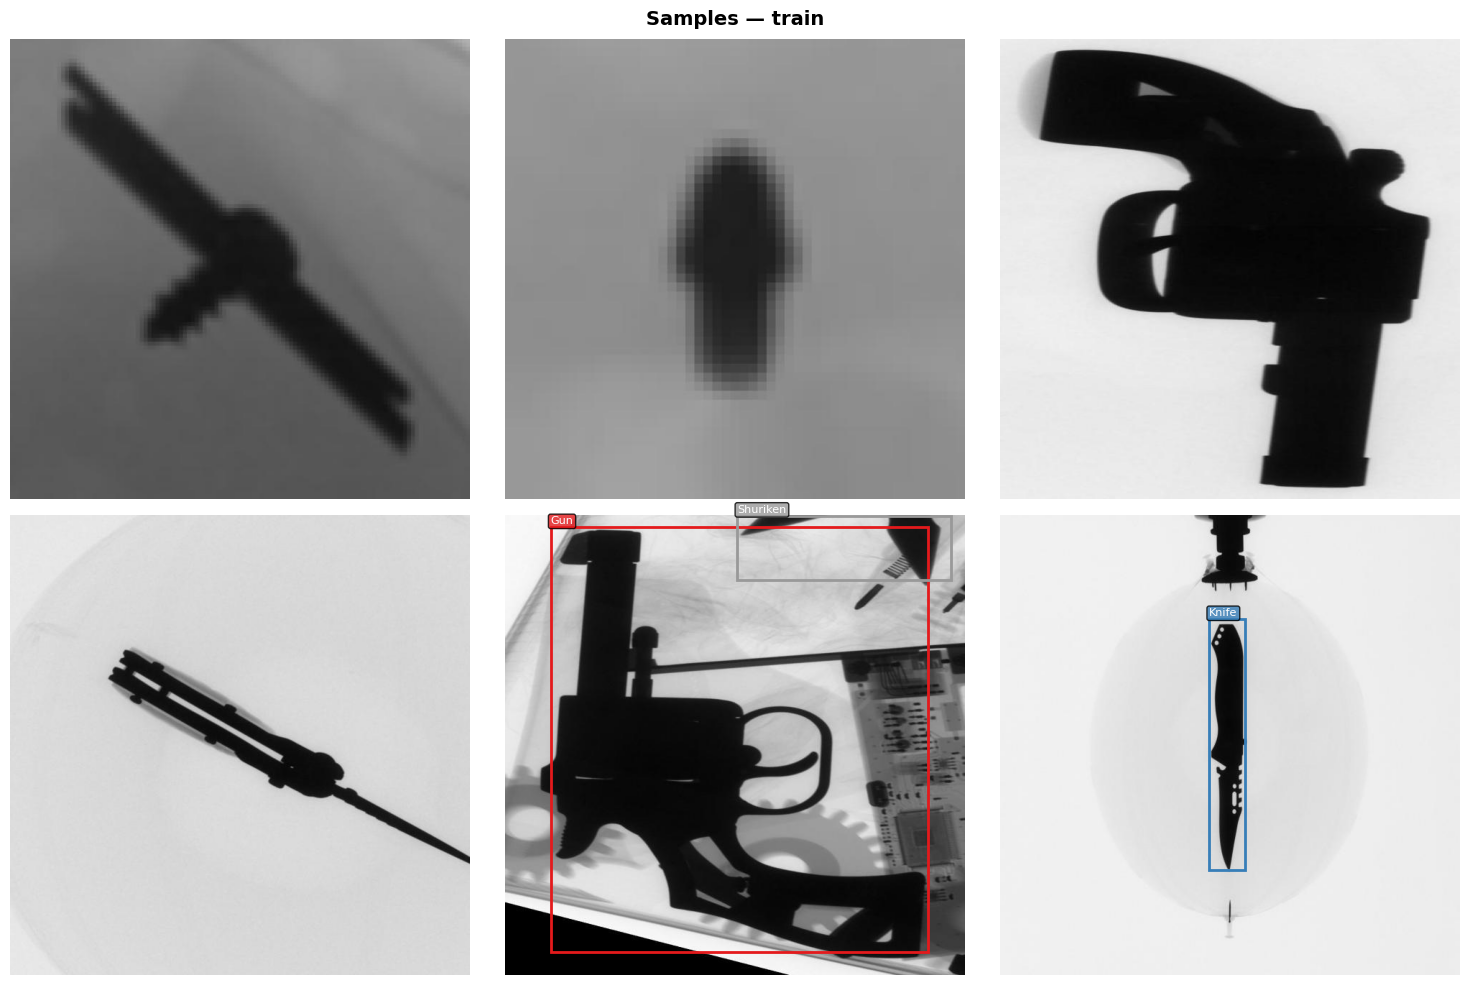

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

def show_samples(dataset_path, split='train', n=6):
    img_dir = dataset_path / split / 'images'
    lbl_dir = dataset_path / split / 'labels'
    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    sample = random.sample(images, min(n, len(images)))
    colors = plt.cm.Set1(np.linspace(0, 1, data_config['nc']))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Samples — {split}', fontsize=14, fontweight='bold')

    for ax, img_path in zip(axes.flatten(), sample):
        img = Image.open(img_path).convert('RGB')
        W, H = img.size
        ax.imshow(img)

        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            for line in open(lbl_path):
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x, y = (cx - bw/2) * W, (cy - bh/2) * H
                    rect = patches.Rectangle((x, y), bw*W, bh*H,
                                             linewidth=2, edgecolor=colors[cls % len(colors)],
                                             facecolor='none')
                    ax.add_patch(rect)
                    label = data_config['names'][cls]
                    ax.text(x, y-4, label, color='white', fontsize=8,
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor=colors[cls % len(colors)], alpha=0.8))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(dataset_path)

**YOLOv8 Training Configuration**

In [ ]:
# 5566 images → yolov8s, 80 epochs, patience 15
MODEL_SIZE   = 'yolov8s'
EPOCHS       = 80
BATCH_SIZE   = 16
IMAGE_SIZE   = 640
PATIENCE     = 15
PROJECT_NAME = 'airport_security'
RUN_NAME     = f'{MODEL_SIZE}_ep{EPOCHS}'

print(f'Model:   {MODEL_SIZE}.pt')
print(f'Epochs:  {EPOCHS}  (early stop: {PATIENCE})')
print(f'Batch:   {BATCH_SIZE}')
print(f'Output:  {PROJECT_NAME}/{RUN_NAME}')

Model:   yolov8s.pt
Epochs:  80  (early stop: 15)
Batch:   16
Output:  airport_security/yolov8s_ep80


**Training the YOLOv8 Object Detection Model**

In [ ]:
from ultralytics import YOLO

model = YOLO(f'{MODEL_SIZE}.pt')

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    project=PROJECT_NAME,
    name=RUN_NAME,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, mixup=0.1,
    plots=True,
    save=True,
    save_period=10,
    workers=2,
    device=0,
    amp=True,
)

print('✅ Training completed!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=Fal

**YOLOv8 Model Validation**

In [ ]:
from ultralytics import YOLO
from pathlib import Path

best_model = YOLO('/content/runs/detect/airport_security/yolov8s_ep80/weights/best.pt')
yaml_path = Path('/content/dataset/data.yaml')

val = best_model.val(data=str(yaml_path), imgsz=640, batch=16, plots=True)

print(f'mAP@0.5:      {val.box.map50:.4f}')
print(f'mAP@0.5:0.95: {val.box.map:.4f}')
print(f'Precision:    {val.box.mp:.4f}')
print(f'Recall:       {val.box.mr:.4f}')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 886.9±480.3 MB/s, size: 24.6 KB)
val: Scanning /content/dataset/valid/labels.cache... 557 images, 152 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 557/557 146.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 230, len(boxes) = 535. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.1it/s 8.5s
                   all        557        535      0.941      0.906      0.913      0.738
                   Gun         90         93      0.985      0.989       0.99      0.895
                 Knife        181       

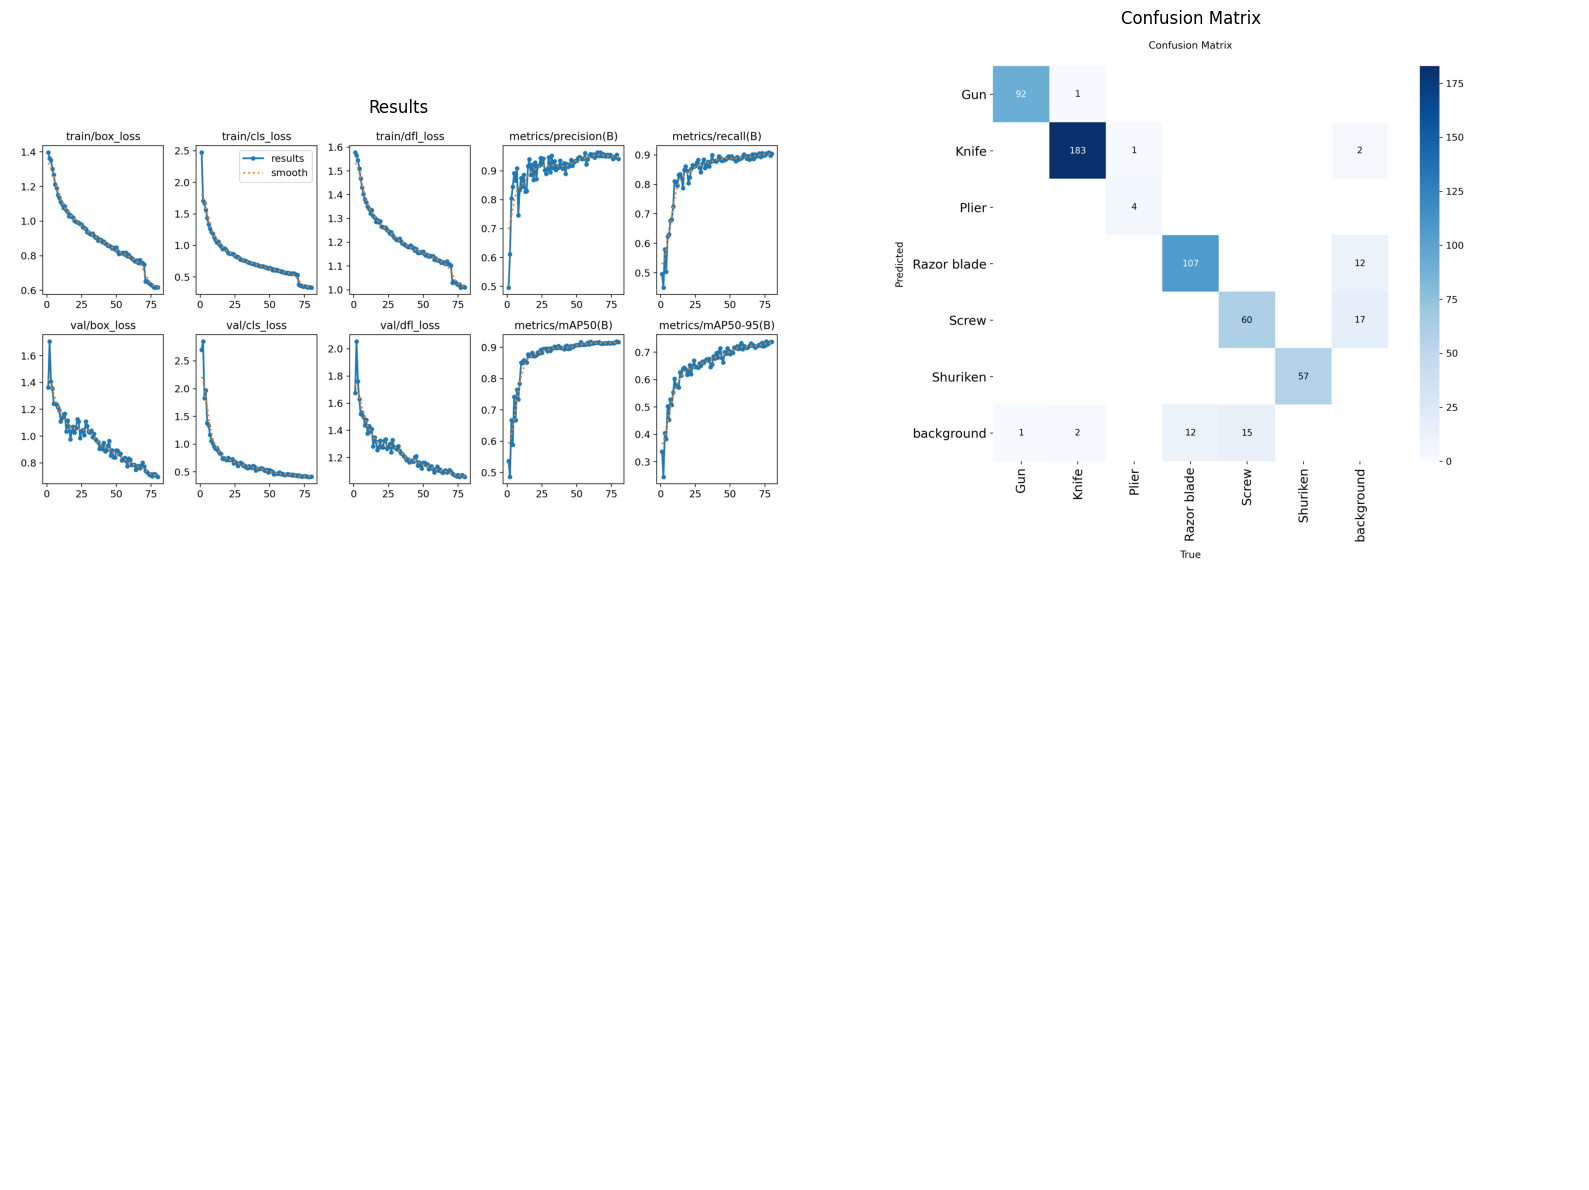

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

run_dir = Path('/content/runs/detect/airport_security/yolov8s_ep80')
plots = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, name in zip(axes.flatten(), plots):
    p = run_dir / name
    if p.exists():
        ax.imshow(mpimg.imread(p))
        ax.set_title(name.replace('.png','').replace('_',' ').title())
    ax.axis('off')

plt.tight_layout()
plt.show()

**Inference on Test Data Using Trained YOLOv8 Model**

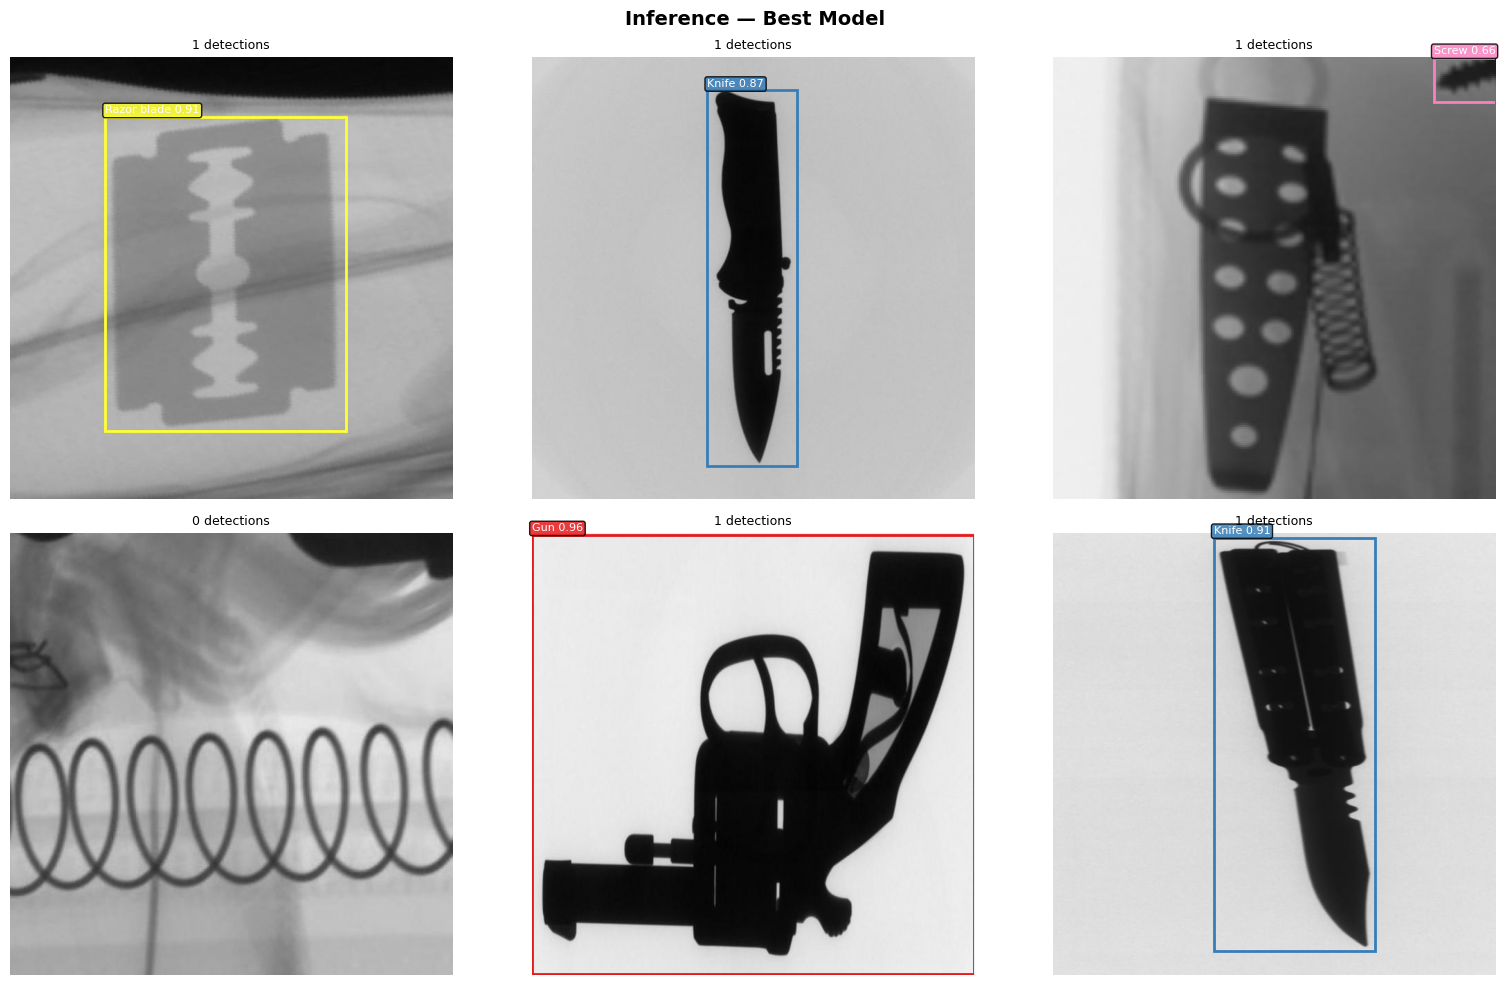

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random
import yaml

dataset_path = Path('/content/dataset')
with open(dataset_path / 'data.yaml') as f:
    data_config = yaml.safe_load(f)

test_imgs = (list((dataset_path / 'test' / 'images').glob('*.jpg')) +
             list((dataset_path / 'test' / 'images').glob('*.png')))
if not test_imgs:
    test_imgs = (list((dataset_path / 'valid' / 'images').glob('*.jpg')) +
                 list((dataset_path / 'valid' / 'images').glob('*.png')))

sample = random.sample(test_imgs, min(6, len(test_imgs)))
preds  = best_model.predict(source=sample, conf=0.25, iou=0.45, verbose=False)
colors = plt.cm.Set1(np.linspace(0, 1, data_config['nc']))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Inference — Best Model', fontsize=14, fontweight='bold')

for ax, (img_path, pred) in zip(axes.flatten(), zip(sample, preds)):
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    if pred.boxes:
        for box in pred.boxes:
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            color = colors[cls % len(colors)]
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                         linewidth=2, edgecolor=color, facecolor='none'))
            ax.text(x1, y1-5, f"{data_config['names'][cls]} {conf:.2f}",
                    color='white', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))
    ax.set_title(f'{len(pred.boxes) if pred.boxes else 0} detections', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interactive Object Detection on User-Provided Images**

Saving B0022_0005_png.rf.ee57c18a45bee5614943237d59c35989.jpg to B0022_0005_png.rf.ee57c18a45bee5614943237d59c35989.jpg
✅ Βρέθηκαν 1 αντικείμενα


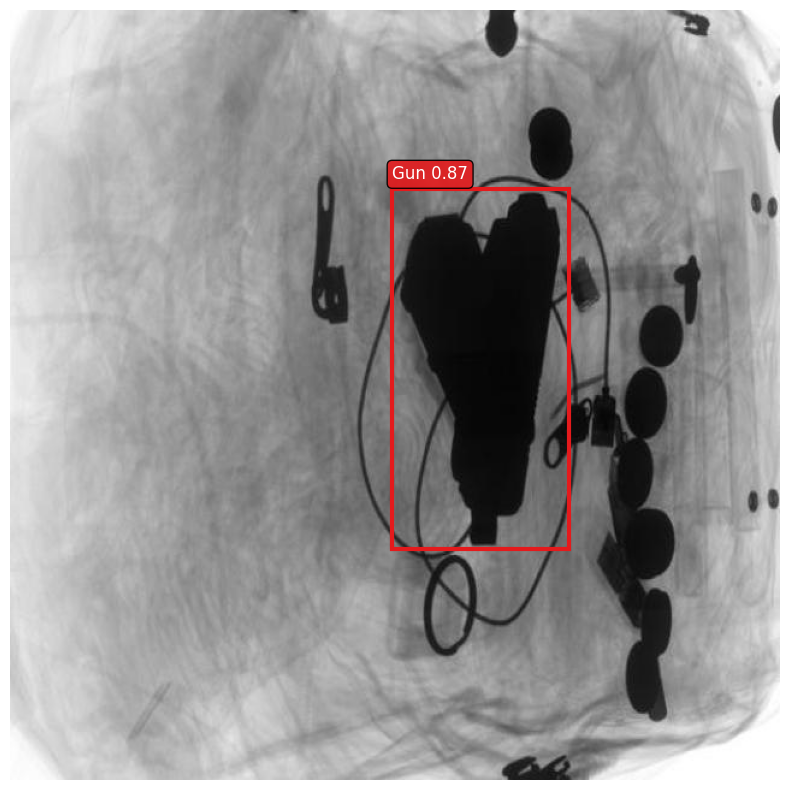

In [ ]:
from google.colab import files
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import yaml
from pathlib import Path

# Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load model
best_model = YOLO('/content/runs/detect/airport_security/yolov8s_ep80/weights/best.pt')

with open('/content/dataset/data.yaml') as f:
    data_config = yaml.safe_load(f)

# Inference
pred = best_model.predict(source=img_path, conf=0.25, iou=0.45, verbose=False)[0]

# Visualization
img = Image.open(img_path).convert('RGB')
colors = plt.cm.Set1(np.linspace(0, 1, data_config['nc']))

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img)

if pred.boxes:
    for box in pred.boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        color = colors[cls % len(colors)]
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                     linewidth=3, edgecolor=color, facecolor='none'))
        ax.text(x1, y1-8, f"{data_config['names'][cls]} {conf:.2f}",
                color='white', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.9))
    print(f'✅ Found {len(pred.boxes)} objects')
else:
    print('❌ No item found — try lower conf=0.10')

ax.axis('off')
plt.tight_layout()
plt.show()